<a/ id='top'></a>

# CSCI4022 Homework 2; Minhashing

## Due Friday, February 9th at 11:59 pm to Canvas and Gradescope

#### Submit this file as a .ipynb with *all cells compiled and run* to the associated dropbox.

***

Your solutions to computational questions should include any specified Python code and results as well as written commentary on your conclusions.  Remember that you are encouraged to discuss the problems with your classmates, but **you must write all code and solutions on your own**.

**NOTES**: 

- Any relevant data sets should be available on Canvas. To make life easier on the graders if they need to run your code, do not change the relative path names here. Instead, move the files around on your computer.
- If you're not familiar with typesetting math directly into Markdown then by all means, do your work on paper first and then typeset it later.  Here is a [reference guide](https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference) linked on Canvas on writing math in Markdown. **All** of your written commentary, justifications and mathematical work should be in Markdown.  I also recommend the [wikibook](https://en.wikibooks.org/wiki/LaTeX) for LaTex.
- Because you can technically evaluate notebook cells is a non-linear order, it's a good idea to do **Kernel $\rightarrow$ Restart & Run All** as a check before submitting your solutions.  That way if we need to run your code you will know that it will work as expected. 
- It is **bad form** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code. 
- 45 points of this assignment are in problems.  The remaining 5 are for neatness, style, and overall exposition of both code and text.
- This probably goes without saying, but... For any question that asks you to calculate something, you **must show all work and justify your answers to receive credit**. Sparse or nonexistent work will receive sparse or nonexistent credit. 
- There is *not a prescribed API* for these problems.  You may answer coding questions with whatever syntax or object typing you deem fit.  Your evaluation will primarily live in the clarity of how well you present your final results, so don't skip over any interpretations!  Your code should still be commented and readable to ensure you followed the given course algorithm.
- There are two ways to quickly make a .pdf out of this notebook for Gradescope submission.  Either:
 - Use File -> Download as PDF via LaTeX.  This will require your system path find a working install of a TeX compiler
 - Easier: Use File ->  Print Preview, and then Right-Click -> Print using your default browser and "Print to PDF"



---
**Shortcuts:**  [Problem 1](#p1) | [Problem 2](#p2) | [Problem 3](#p3) |
---


In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import string

***
<a/ id='p1'></a>
[Back to top](#top)
# Problem 1 (Theory: minimal Permutations; 9 pts)

Consider minhash values for a single column vector that contains 6 components/rows. Four of rows hold 0 and two hold 1. Consider taking all 6! = 720 possible distinct permutations of the six rows. When we choose a permutation of the rows and produce a minhash value for the column, we will use the number of the row, in the permuted order, that is the first with a 1.  Assume that we are 0-indexing when we return the minhash value for a permutation.  Use counting/probability/math in Markdown cells to demonstrate answers to the following, although you may check your work or logic with code/Python.

### a) For exactly how many of the 720 permutations is the minhash value for the column a 5?  What proportion/probability is this?

The probability is 0 because since there are two rows with a 1 it is impossible for the first row with a 1 to be the last row.

### b) For exactly how many of the 720 permutations is the minhash value for the column a 4?  What proportion/probability is this?

The probability of this is $\frac{1}{15}$ because in order for the minhash value to be 4 the combination has to be 0 0 0 0 1 1, so there is only 1 way to make it out of 15 total combinations

### c) For exactly how many of the 720 permutations is the minhash value for the column a 2?  What proportion/probability is this?

The probability is $\frac{4}{15}$ because there are four different combinations where the first 1 is in the 3rd place. 0 1 1 0 0 0, 0 1 0 1 0 0, 0 1 0 0 1 0 and 0 1 0 0 0 1.

***
<a/ id='p2'></a>
[Back to top](#top)
# Problem 2 (Permutations and Hashing; 6 pts)

In class we presented the result that hash functions can behave as **approximate** permutations.  We might, however, be interested in whether or not they are actually randomly selecting from all possible permutations, or if they might somehow be more limited and not "choose" some options.

### a) Using Markdown cells and as much rigor as you can, prove or disprove the following claim:

Given a characteristic matrix with prime $n$ rows, hash functions of the form $h(r)=ar+b \mod n$ can provide each and every possible permutation of $n$ objects, where $0 < a, b < n$ are integers.


With n rows there are n! possible permutations. With n rows, there are $(n-1)^2$ combinations of a and b, so there are $(n-1)^2$ permutations of the hash function. If n = 5, then there are 120 possible permutations of the rows and there are 16 possible combinations of the hash function. SO therefore the hash function cannot provide each and every possible permutations of the rows.



### b) Using Markdown cells, argue in favor or in opposition to the following claim, using as much rigor as you can:
Given a characteristic matrix with prime $n$ rows, hash functions of the form $h(r)=ar+b \mod p$ can provide each and every possible permutation of $n$ objects, where $0 < a, b < p$ are integers and $p>n$ is prime.

If there are n row then there are n! possible permutations, and if p = n+1 then there are $n^2$ possible permutations of the hash function, and $n^2 != n!$. So if p is close to n then the claim is false, but if you pick a p much larger than n, such as n=5 and p=13, then you can create every possible permutation. There would be 120 possible permutations of the rows and you could create a max of $(13-1)^2 = 144$ possible permutations with the hash function. So I guess I'm not really arguing in either direction, more in the middle, p has to be significantly greater than n for the claim to be true, but if p is too close to n the claim is false.

Hint: As always with any proof that's a "prove or disprove" claim, try to convince yourself whether the claim is true or false by playing around with small objects, like $n=3$ or $n=5$.  Can you *constructively* make all possible permutations, or are some impossible?

Try to be rigorous, but a well thought out written argument will suffice as well.

***
<a/ id='p3'></a>
[Back to top](#top)
# Problem 3 (Applied Minhashing; 30 pts)

In this problem we compare similarities of 6 documents available on http://www.gutenberg.org

1) The first approximately 10000 characters of Alexander Dumas' *The Count of Monte Cristo*, written in French, in the file `countmc.txt`
 
 2) The first approximately 10000 characters of Victor Hugo *Les Miserables*, written in French, in the file `lesmis.txt`
 
 3) The first approximately 10000 characters of Jules Verne's *20,000 Leagues Under the Sea*, written in French and translated into English by Frederick Paul Walter, in the file `leagues.txt`
 
 4) The first approximately 10000 characters of Kate Chopin's *The Awakening* in the file `awaken.txt`
 
 5) The entirety of around 12000 characters of Kate Chopin's *Beyond the Bayou* in the file `BB.txt`
 
 6) The first approximately 10000 characters of Homer's *The Odyssey*, translated into English by Samuel Butler, in the file `odyssey.txt`

 
### a) Clean the 6 documents, scrubbing all punctuation, changes cases to lower case, and removing accent marks as appropriate.  


**For this problem, you may import any text-based packages you desire to help wrangle the data.**  I recommend looking at some functions within `string` or the RegEx `re` packages.

You can and probably should use functions in the string package such as `string.lower`, `string.replace`, etc.

All 6 documents have been saved in UTF-8 encoding.

After processing, you should have (at most) 27 unique characters in each book/section after cleaning, corresponding to white spaces and the 26 letters.  Print out the set of unique characters to ensure this.




In [57]:
import unicodedata

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace("\n", " ")
    text = text.replace("_", "")
    text = text.replace(".","")
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')
    text = text.replace("   ", " ")
    text = text.replace("  ", " ")
    return text

documents = {}
for filename in ['countmc.txt', 'lesmis.txt', 'leagues.txt', 'awaken.txt', 'BB.txt', 'odyssey.txt']:
    with open(filename, 'r', encoding='utf-8') as file:
        cleaned_contents = clean_text(file.read())
        print("Unique Characters: ", set(cleaned_contents), "Number of chars: ", len(set(cleaned_contents)))
        documents[filename] = cleaned_contents

Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'p', 'r', 'e', 'f', 'y', 'o', 'a', 'z', 'c', 's', 'u', 'b', 'j', 'v', 'n'} Number of chars:  25
Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'p', 'r', 'e', 'f', 'y', 'o', 'a', 'z', 'c', 's', 'u', 'b', 'j', 'v', 'n'} Number of chars:  25
Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'w', 'p', 'r', 'e', 'f', 'k', 'y', 'o', 'a', 'z', 'c', 's', 'u', 'b', 'j', 'v', 'n'} Number of chars:  27
Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'w', 'p', 'r', 'e', 'f', 'k', 'y', 'o', 'a', 'z', 'c', 's', 'u', 'b', 'j', 'v', 'n'} Number of chars:  27
Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'w', 'p', 'r', 'e', 'f', 'k', 'y', 'o', 'a', 'z', 'c', 's', 'u', 'b', 'j', 'v', 'n'} Number of chars:  27
Unique Characters:  {' ', 'l', 'x', 'g', 'h', 't', 'q', 'i', 'm', 'd', 'w', 'p', 'r', 'e', 'f', 'k', 'y', 'o', 'a', 'z', 'c', 's', 'u',


### b) Compute exact similarity scores between the documents.  Are these the expected results?

Notes:
- You should choose or explore different values of $k$ for your shingles and report the results for multiple values of $k$.  Which values create the largest **range** of similarity scores?
- You may choose to shingle on words and create an n-gram model, but it is recommended you shingle on letters as described in class
- You may construct your characteristic matrix or characteristic sets with or without hash functions (e.g. by using Python's `set` methods).  Note that choice of hash function should change heavily with $k$!

Jaccard similarity between countmc.txt and lesmis.txt: 0 using k=0
Jaccard similarity between countmc.txt and leagues.txt: 0 using k=0
Jaccard similarity between countmc.txt and awaken.txt: 0 using k=0
Jaccard similarity between countmc.txt and BB.txt: 0 using k=0
Jaccard similarity between countmc.txt and odyssey.txt: 0 using k=0
Jaccard similarity between lesmis.txt and leagues.txt: 0 using k=0
Jaccard similarity between lesmis.txt and awaken.txt: 0 using k=0
Jaccard similarity between lesmis.txt and BB.txt: 0 using k=0
Jaccard similarity between lesmis.txt and odyssey.txt: 0 using k=0
Jaccard similarity between leagues.txt and awaken.txt: 0 using k=0
Jaccard similarity between leagues.txt and BB.txt: 0 using k=0
Jaccard similarity between leagues.txt and odyssey.txt: 0 using k=0
Jaccard similarity between awaken.txt and BB.txt: 0 using k=0
Jaccard similarity between awaken.txt and odyssey.txt: 0 using k=0
Jaccard similarity between BB.txt and odyssey.txt: 0 using k=0

Jaccard simila


Jaccard similarity between countmc.txt and leagues.txt: 0.37 using k=3
Jaccard similarity between countmc.txt and awaken.txt: 0.33 using k=3
Jaccard similarity between countmc.txt and BB.txt: 0.34 using k=3
Jaccard similarity between countmc.txt and odyssey.txt: 0.32 using k=3
Jaccard similarity between lesmis.txt and leagues.txt: 0.36 using k=3
Jaccard similarity between lesmis.txt and awaken.txt: 0.34 using k=3
Jaccard similarity between lesmis.txt and BB.txt: 0.34 using k=3
Jaccard similarity between lesmis.txt and odyssey.txt: 0.32 using k=3
Jaccard similarity between leagues.txt and awaken.txt: 0.5 using k=3
Jaccard similarity between leagues.txt and BB.txt: 0.5 using k=3
Jaccard similarity between leagues.txt and odyssey.txt: 0.49 using k=3
Jaccard similarity between awaken.txt and BB.txt: 0.54 using k=3
Jaccard similarity between awaken.txt and odyssey.txt: 0.5 using k=3
Jaccard similarity between BB.txt and odyssey.txt: 0.52 using k=3

Jaccard similarity between countmc.txt an

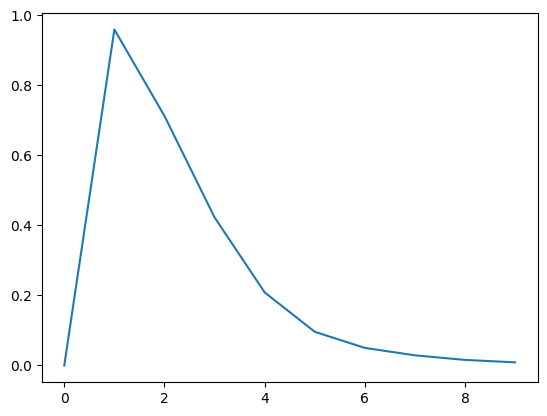

In [58]:
def create_shingles(doc, k):
    shingles = set()
    for i in range(len(doc)-k+1):
        shingles.add(doc[i:i+k])
    return shingles

def calc_similarity(doc1, doc2):
    intersection_size = 0
    union_size=0
    for i in range(len(doc1)-1):
        if(doc1[i]==1 and doc2[i]==1):
            intersection_size+=1
        if(doc1[i]==1 or doc2[i]==1):
            union_size+=1
    if(union_size==0):
        return 0
    return intersection_size/union_size

def run(k):
    matrix = [[]]
    allShingles = set()
    for file in documents:
        allShingles.update(create_shingles(documents[file], k))
    allShingles = list(allShingles)
    matrix = [[0] * 6 for _ in range(len(allShingles))]
    for i,file in enumerate(documents):
        for j,shingle in enumerate(allShingles):
            if shingle in documents[file]:
                matrix[j][i] = 1

    sim_list = []
    i=0
    similarities = np.zeros(15)
    count = 0
    for f1 in documents:
        j=0
        for f2 in documents:
            if(f1!=f2 and (f1,f2) not in sim_list and (f2,f1) not in sim_list):
                document1 = []
                document2 = []
                for row in matrix:
                    document1.append(row[i])
                    document2.append(row[j])
                similarity = calc_similarity(document1, document2)
                sim_list.append((f1,f2))
                print(f"Jaccard similarity between {f1} and {f2}: {round(similarity,2)} using k={k}")
                similarities[count] = similarity 
                count+=1
            j+=1
        i+=1
    print()
    return matrix,similarities

means=[]
max_range=0
max_k_range=0
max_range_matrix = []
for i in range(10):
    saved_matrix,sim = run(i)
    means.append(np.mean(sim))
    if(np.ptp(sim)>max_range):
        max_range = np.ptp(sim)
        max_k_range=i
        max_range_matrix = saved_matrix
print(max_k_range,max_range)
print(len(max_range_matrix))
plt.plot(means)
plt.show()

### c) Implement minhashing with 1000 hash functions on the 6 documents, checking your results against those in part b).

- You may choose your own value of $p$ as the modulus of the hash functions.  You are encouraged to use the example code from the minhashing in class notebook to start you out.

In [59]:
#copied from notebook
def minhash(nhash, dfC):
    '''
    Takes a number of hash functions to use (nhash) and characteristic matrix (dfC)
    '''
    # use the "universal hash":  (a*x+b) mod p, where a, b are random ints and p > N (= 10 here) is prime
    np.random.seed(4022)
    Ahash = np.random.choice(range(0,10000), size=nhash)
    Bhash = np.random.choice(range(0,10000), size=nhash)
    Phash = 3797

    # STEP 2:  initialize signature matrix to all infinities

    # initialize the signature matrix
    Msig = np.full([nhash, len(dfC.columns)], fill_value=np.inf)

    # fill in the signature matrix:

    # For each row of the characteristic matrix... 
    hash_vals = [0]*nhash # initialize
    for r in range(len(dfC)):
        # STEP 3:  Compute hash values (~permuted row numbers) for that row under each hash function
        for h in range(nhash):
            hash_vals[h] = (Ahash[h]*r + Bhash[h])%Phash
        # STEP 4:  For each column, if there is a 0, do nothing...
        for c in range(len(dfC.columns)):
            # ... but if there is a 1, replace signature matrix element in that column for each hash fcn 
            # with the minimum of the hash value in this row, and the current signature matrix element
            if dfC.iloc[r,c]==1:
                for h in range(nhash):
                    if hash_vals[h] < Msig[h,c]:
                        Msig[h,c] = hash_vals[h]
    return Msig

num_hash_functions = 1000

signature_matrix = minhash(num_hash_functions,pd.DataFrame(max_range_matrix, columns=['countmc.txt', 'lesmis.txt', 'leagues.txt', 'awaken.txt', 'BB.txt', 'odyssey.txt']))
i=0
sim_list = []
for f1 in documents:
    j=0
    for f2 in documents:
        if(f1!=f2 and (f1,f2) not in sim_list and (f2,f1) not in sim_list):
            document1 = []
            document2 = []
            for row in signature_matrix:
                document1.append(row[i])
                document2.append(row[j])
            similarity = sum(np.array(document1)==np.array(document2))/len(document1)
            sim_list.append((f1,f2))
            print(f"Jaccard similarity between {f1} and {f2}: {round(similarity,2)} using k={3}")
        j+=1
    i+=1



Jaccard similarity between countmc.txt and lesmis.txt: 0.56 using k=3
Jaccard similarity between countmc.txt and leagues.txt: 0.37 using k=3
Jaccard similarity between countmc.txt and awaken.txt: 0.32 using k=3
Jaccard similarity between countmc.txt and BB.txt: 0.35 using k=3
Jaccard similarity between countmc.txt and odyssey.txt: 0.32 using k=3
Jaccard similarity between lesmis.txt and leagues.txt: 0.34 using k=3
Jaccard similarity between lesmis.txt and awaken.txt: 0.33 using k=3
Jaccard similarity between lesmis.txt and BB.txt: 0.35 using k=3
Jaccard similarity between lesmis.txt and odyssey.txt: 0.34 using k=3
Jaccard similarity between leagues.txt and awaken.txt: 0.48 using k=3
Jaccard similarity between leagues.txt and BB.txt: 0.49 using k=3
Jaccard similarity between leagues.txt and odyssey.txt: 0.49 using k=3
Jaccard similarity between awaken.txt and BB.txt: 0.51 using k=3
Jaccard similarity between awaken.txt and odyssey.txt: 0.48 using k=3
Jaccard similarity between BB.txt an



### d) Discussion:

Can we detect expected differences here?  Are the two French documents most similar to each other?  Are the two documents by the same author, with the same theme, the most similar?  Is the French-to-English text the most similar English text when compared to the French texts? What kind of alternatives might have captured the structures between these texts?



The results we got make sense. The two most similar documents are the two french documents, and the two documents written by Kate Chopin are also very similar. Comparing the two french texts to the other texts they are most similar to leagues.txt which was translated from French. It looks like our comparisons worked and produced the kind of results that I would expect from these texts. The French ones are most similar to each other and the ones written by the same author are also very similar.